# Hypothesis check

The motivation for this hypothesis is profoundly based on the properties of the AUC and calibrated PD-models.

On one hand the AUC measures the discrimination power of a scoring system. This has nothing to do with the scoring system being calibrated.

However a model that calculates well the probability of default, meaning a well calibrated model $p$ in the sense
$$
p(x) \approx \mathbb{P}(Y=1 | X = x),
$$

should be a suitable basis to predict "an expected AUC" through monte carlo simulations. If this is true at least
the unbiased logit estimator for the very simple GDP should usually give this results.

## Checking out the default run

In [ ]:
import torch

import os
import sys
base_path = os.path.abspath("./..")
if base_path not in sys.path:
    sys.path.append(base_path)

from berebasl.simulation.credit_data_simulation import CreditData, CreditDataGenerator
from berebasl.evaluation.batched_metrics import batched_auroc
from berebasl.estimation.classifiers import TorchLogistic

In [ ]:
device = torch.device(
        "cuda" if torch.cuda.is_available() else 
        "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else 
        "cpu"
    )

sim_path = '../berebasl/data/simulations/default_sim'

sim_results_path = os.path.join(sim_path, 'simulation_results.pt')
init_objs_path = os.path.join(sim_path, 'initial_simulation_objects.pt')
sim_results = torch.load(sim_results_path, map_location='cpu', weights_only=False)
init_objs = torch.load(init_objs_path, map_location='cpu', weights_only=False)

credit_data: CreditData = sim_results["credit_data"].to(device)
data_generator: CreditDataGenerator = init_objs['data_generator']

In [5]:
_, lbls = credit_data.accepts()
print("Checking out all accepts")
accept_count = lbls.size(0)
print("\tCount accepts:", accept_count)
defaults = lbls.sum().to(int).item()
print("\tDefaults among accepts:", defaults)
print("\tRate of Defaults among accepts:", defaults/accept_count)

_, lbls = credit_data.accepts(from_round_idx=1)
print("Checking out accepts without the first round")
accept_count = lbls.size(0)
print("\tCount accepts:", accept_count)
defaults = lbls.sum().to(int).item()
print("\tDefaults among accepts:", defaults)
print("\tRate of Defaults among accepts:", defaults/accept_count)


Checking out all accepts
	Count accepts: 6020
	Defaults among accepts: 144
	Rate of Defaults among accepts: 0.023920265780730896
Checking out accepts without the first round
	Count accepts: 5980
	Defaults among accepts: 140
	Rate of Defaults among accepts: 0.023411371237458192


In [3]:
#data_generator: CreditDataGenerator = init_objs['data_generator']

data_generator.bayes_error_rate()

0.1298000067472458

In [3]:
last_gen_round_idx = credit_data.last_gen_round.item()
for state_dict_gen in sim_results['classifiers_state_dicts']:
    gen_round_idx = state_dict_gen["gen_round_nr"] - 1
    if gen_round_idx == last_gen_round_idx:
        continue
    oracle_classifier = TorchLogistic.instantiate_from_state_dict(state_dict_gen['classifiers']['oracle_classifier'], device)
    feats_acc, labels_acc = credit_data.accepts(include_gen_round=False, up_to_round_idx=gen_round_idx)
    feats_acc_next_round, labels_acc_next_round = credit_data.accepts(include_gen_round=False, from_round_idx=gen_round_idx+1, up_to_round_idx=gen_round_idx+1)
    break

In [27]:
_, lbls_accept_after_init = credit_data.accepts(from_round_idx=1)

lbls_accept_after_init.sum()/lbls_accept_after_init.size(0)

tensor(0.9916, dtype=torch.float64)

In [7]:
oracle_classifier.predict_proba(feats_acc_next_round)[:,1]

tensor([0.9513, 0.9756, 0.8750, 0.8948, 0.9997, 0.9122, 0.9984, 0.9970, 0.9993,
        0.9888, 0.9987, 0.9401, 0.9999, 0.9968, 0.9817, 0.9701, 0.9523, 0.9911,
        0.9916, 1.0000], dtype=torch.float64, grad_fn=<SelectBackward0>)

In [ ]:
if True:
    feats_acc, labels_acc = credit_data.accepts(include_gen_round=False, up_to_round_idx=gen_round_idx)

    feats_acc_next_round, labels_acc_next_round = credit_data.accepts(include_gen_round=False, from_round_idx=gen_round_idx+1, up_to_round_idx=gen_round_idx+1)

## Step 1: Make GDP less easy

The GDP shows a too well linearly separable problem, such that it is highly unrealistic. A first generation showed highly unrealistic false positive rate of **98,57%** among accepts, meaning the decision was right almost always, among those a lot of the defaults come from the initial generation round, such that when leaving it out the FPR was **99,16%** -> absolute nonsense

In [2]:
from berebasl.simulation.credit_data_simulation import CreditDataGenerator
from berebasl.simulation.acceptance_loop import default_dgp

dtype = torch.float64
torch.set_default_dtype(dtype)
device = torch.device(
    "cuda" if torch.cuda.is_available() else 
    "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else 
    "cpu"
)

dgp = default_dgp(seed_credit_data_gen=1807, deterministic_weights_for_mixture_sampling=True, device=device, dtype=dtype)

In [4]:
print("mu_good =", dgp.good_mixture.mean, "mu_bad =", dgp.bad_mixture.mean)
print("sigma_good = ", dgp.good_mixture.cov)
print("sigma_bad =", dgp.bad_mixture.cov)

mu_good = tensor([1., 2.]) mu_bad = tensor([0., 0.])
sigma_good =  tensor([[ 1.0000, -0.2000],
        [-0.2000,  1.0000]])
sigma_bad = tensor([[1.0000, 0.2000],
        [0.2000, 1.0000]])


In [3]:
device = torch.device(
        "cuda" if torch.cuda.is_available() else 
        "mps" if getattr(torch.backends, "mps", None) and torch.backends.mps.is_available() else 
        "cpu"
    )

sim_path = '../berebasl/data/simulations/simulation_20260215_085247'

sim_results_path = os.path.join(sim_path, 'simulation_results.pt')
init_objs_path = os.path.join(sim_path, 'initial_simulation_objects.pt')
sim_results = torch.load(sim_results_path, map_location='cpu', weights_only=False)
init_objs = torch.load(init_objs_path, map_location='cpu', weights_only=False)

credit_data: CreditData = sim_results["credit_data"].to(device)
data_generator: CreditDataGenerator = init_objs['data_generator']

In [ ]:
from berebasl.utils.normalized_shape_tensor_ops import k_fold_cv_normalized_split



In [ ]:
accepts_based_classif = TorchLogistic(
    n_features=credit_data.features_count, 
    dtype=credit_data.features.dtype,
    device=credit_data.device
)
oracle_classif = TorchLogistic(
    n_features=credit_data.features_count, 
    dtype=credit_data.features.dtype,
    device=credit_data.device
)

total_gens = credit_data.last_gen_round.item() + 1
gen_count_ahead_of_time = round(total_gens*0.05)
min_gens_passed = round(total_gens*0.1)

min_bads = 4
k_folds = 4

hist_steps_to_check_out = total_gens-gen_count_ahead_of_time - min_gens_passed
auc_exp_acc_based = credit_data.features.new_full((hist_steps_to_check_out, k_folds), fill_value=-1)
auc_real_acc_based = auc_exp_acc_based.new_full((hist_steps_to_check_out, ), fill_value=-1)
auc_exp_unbiased = auc_exp_acc_based.new_full((hist_steps_to_check_out, k_folds), fill_value=-1)
auc_real_unbiased = auc_exp_acc_based.new_full((hist_steps_to_check_out, ), fill_value=-1)


for hist_up_to_gen_idx in range(min_gens_passed, total_gens-gen_count_ahead_of_time):
    historic_data = credit_data.to_sample_dataset(up_to_round_idx=hist_up_to_gen_idx)
    hist_feats_unbiased, hist_lbls_unbiased = credit_data.unbiased_obs(up_to_round_idx=hist_up_to_gen_idx)
    future_data = credit_data.to_sample_dataset(
        from_round_idx=hist_up_to_gen_idx+1, 
        up_to_round_idx=hist_up_to_gen_idx+gen_count_ahead_of_time
    )

    idx_buffer = hist_up_to_gen_idx-min_gens_passed

    auc_exp_acc_based[idx_buffer] = k_fold_evaluate_au_roc(
        feats=historic_data.features_labeled, 
        labels=historic_data.labels,
        rng=historic_data.rng,
        k_folds=k_folds,
        min_bads=min_bads,
        classif=accepts_based_classif
    )
    accepts_based_classif.train()
    accepts_based_classif.reset_parameters_to_initial()
    accepts_based_classif.fit(historic_data.features_labeled, 
                              historic_data.labels)
    accepts_based_classif.eval()
    with torch.no_grad():
        auc_real_acc_based[idx_buffer] = batched_auroc(
            scores=accepts_based_classif.predict_proba(future_data.features_labeled)[:, 1],
            targets=future_data.labels
        )

    auc_exp_unbiased[idx_buffer] = k_fold_evaluate_au_roc(
        feats=hist_feats_unbiased,
        labels=hist_lbls_unbiased,
        rng=historic_data.rng,
        k_folds=k_folds,
        min_bads=min_bads,
        classif=oracle_classif
    )
    oracle_classif.train()
    oracle_classif.reset_parameters_to_initial()
    oracle_classif.fit(hist_feats_unbiased, hist_lbls_unbiased)
    oracle_classif.eval()
    with torch.no_grad():
        auc_real_unbiased[idx_buffer] = batched_auroc(
            scores=oracle_classif.predict_proba(future_data.features_labeled)[:, 1],
            targets=future_data.labels
        )

    if (idx_buffer+1)%25 == 0:
        print("Finished round", idx_buffer, "from", hist_steps_to_check_out)

Finished round 24 from 255
Finished round 49 from 255
Finished round 74 from 255
Finished round 99 from 255
Finished round 124 from 255
Finished round 149 from 255
Finished round 174 from 255
Finished round 199 from 255
Finished round 224 from 255
Finished round 249 from 255


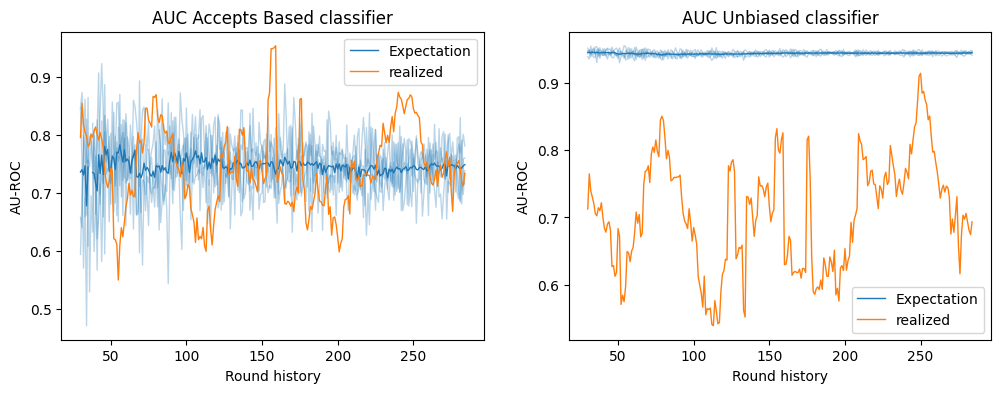

In [ ]:
from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
#from matplotlib.collections import LineCollection

rounds_idx = torch.arange(min_gens_passed, total_gens-gen_count_ahead_of_time, device=credit_data.device)

colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
color_expectation = colors[0]
color_realized = colors[1]

fig, axes = plt.subplots(ncols=2, figsize=(12,4))


for ax, exp, real, which in zip(axes, [auc_exp_acc_based, auc_exp_unbiased], [auc_real_acc_based, auc_real_unbiased], ["Accepts Based", "Unbiased"]):
    ax.plot(rounds_idx, exp.mean(dim=-1).detach(), c=color_expectation, lw=1, label="Expectation")
    for k in range(k_folds):
        ax.plot(rounds_idx, exp[:, k].detach(), c=mcolors.to_rgb(color_expectation) + (0.3,), lw=1)

    ax.plot(rounds_idx, real.detach(), c=color_realized, lw=1, label="realized")

    ax.set_ylabel("AU-ROC")
    ax.set_xlabel("Round history")
    ax.set_title("AUC " + which + " classifier")
    ax.legend()

plt.show()

In [ ]:


k = 2

feats, lbls = k_fold_cv_normalized_split(features=hist_feats_unbiased, labels=hist_lbls_unbiased, rng=historic_data.rng, k=k)

In [ ]:
# Linears are K nn.Linear layers which represent
# the linear estimator of a logit.
weights = torch.stack([l.weight.data.T for l in linears]) # [K, F, 1]
biases = torch.stack([l.bias.data for l in linears]) # [K]


# feats.shape[K, N, F]
logits = torch.bmm(feats, weights).squeeze(-1) + biases # [K, N]

loss_fn_unreduced = torch.nn.BCEWithLogitsLoss(reduction="none")
# lbls.shape = [K, N]
unreduced_losses = loss_fn_unreduced(logits, lbls)

loss_per_batch = unreduced_losses.mean(dim=-1) # [K]

In [110]:
unreduced_losses.shape

torch.Size([2, 14300])

In [96]:
weights.shape

torch.Size([2, 2, 1])

In [97]:
biases.shape

torch.Size([2, 1])

In [103]:
results = torch.bmm(feats, weights).squeeze(-1) + biases

In [104]:
results_manual = torch.stack([c(f) for f, c in zip(feats, [accepts_based_classif, oracle_classif])])

In [106]:
torch.max(torch.abs(results_manual - results))

tensor(0., dtype=torch.float64, grad_fn=<MaxBackward1>)